In [5]:


import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import transforms

from groupy.gconv.pytorch_gconv.splitgconv2d import P4ConvZ2, P4ConvP4
from groupy.gconv.pytorch_gconv import P4MConvZ2, P4MConvP4M
from groupy.gconv.pytorch_gconv.pooling import plane_group_spatial_max_pooling

class NNet(nn.Module):
    def __init__(self, in_channels, out_channels):
        super(NNet, self).__init__()
        

        self.conv1 = P4MConvZ2(in_channels, 32, kernel_size=3, stride=1, padding=1)
        self.conv2 = P4MConvP4M(32, 32, kernel_size=3, stride=1, padding=1)

        self.conv3 = P4MConvP4M(32, 64, kernel_size=3, stride=1, padding=1)
        self.conv4 = P4MConvP4M(64, 128, kernel_size=3, stride=1, padding=1)

        self.conv5 = P4MConvP4M(128, 64, kernel_size=3, padding=1)
        self.conv6 = P4MConvP4M(64, 32, kernel_size=3, padding=1)

        self.convt = nn.ConvTranspose2d(32*8, out_channels, kernel_size=2, stride=2, output_padding=0)


    def forward(self, x):
        x = F.relu(self.conv1(x))
        x = F.relu(self.conv2(x))
        x = plane_group_spatial_max_pooling(x, 2, 2)
        x = F.relu(self.conv3(x))
        x = F.relu(self.conv4(x))
        x = F.relu(self.conv5(x))
        x = F.relu(self.conv6(x))
        xs = x.size()
        x = x.view(xs[0], xs[1] * xs[2], xs[3], xs[4])
#         x = F.avg_pool2d(x, 2, 2)
        x = self.convt(x)

        return x


def load_models():
    p4m = NNet(1, 1)
    p4m.load_state_dict(torch.load('NNet_groupy_p4m_v2_VecAdam.pth'))

#     p4m_adaptive = NNet(1, 1)
#     p4m_adaptive.load_state_dict(torch.load('NNet_groupy_p4m_v2_VecAdam_adaptive.pth'))

    return p4m



def process_op(imgpath, model):
    image = Image.open(imgpath)
    transform = transforms.Compose([
        transforms.ToTensor(),
    ])

    image = transform(image)
    image = image.unsqueeze(0)  # Add batch dimension

    model.eval()
    with torch.no_grad():
        output = model(image)

    # Convert the output to probabilities by applying the sigmoid activation
    output_probs = torch.sigmoid(output)

    # Convert tensors to numpy arrays for visualization
    output_probs_np = output_probs.cpu().squeeze().numpy()

    norm = (output_probs_np - output_probs_np.min()) / (output_probs_np.max() - output_probs_np.min())

    rb = restoration.rolling_ball(norm)
    subt = norm - rb

#     return subt
#     thr = threshold_otsu(subt)
    thr = threshold_minimum(subt)

    subt2 = copy.deepcopy(subt)

    subt2[subt < thr] = 0.
    subt2[subt >= thr] = 255.

    return subt2

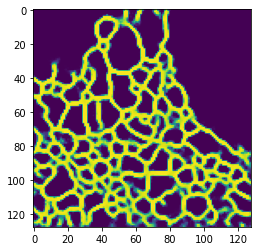

In [52]:
from PIL import Image
from skimage import restoration
model = load_models()

imgpath = '/localhome/asa420/MIAL/data/confocal-data/ATL/std/A6_decon_t040_ch00_std.png'
subt = process_op(imgpath, model)

import matplotlib.pyplot as plt
plt.imshow(subt)

In [53]:
from skimage.filters import threshold_local, threshold_minimum, threshold_multiotsu, \
threshold_otsu, threshold_isodata, threshold_li, threshold_mean, threshold_niblack, \
threshold_sauvola, threshold_triangle, threshold_yen
loc = threshold_local(subt, 5)

tmin = threshold_minimum(subt)
mul = threshold_multiotsu(subt)
ot = threshold_otsu(subt)
iso = threshold_isodata(subt)
li = threshold_li(subt)
mn = threshold_mean(subt)
nib = threshold_niblack(subt)
sauv = threshold_sauvola(subt)
tt = threshold_triangle(subt)
yn = threshold_yen(subt)

In [54]:
print(tmin)
print(mul)
print(ot)
print(iso)
print(li)
print(mn)
print(tt)
print(yn)

0.3710072
[0.25057554 0.71287775]
0.46812952
0.46812952
0.18082786
0.31235301
0.013597123
0.00971223


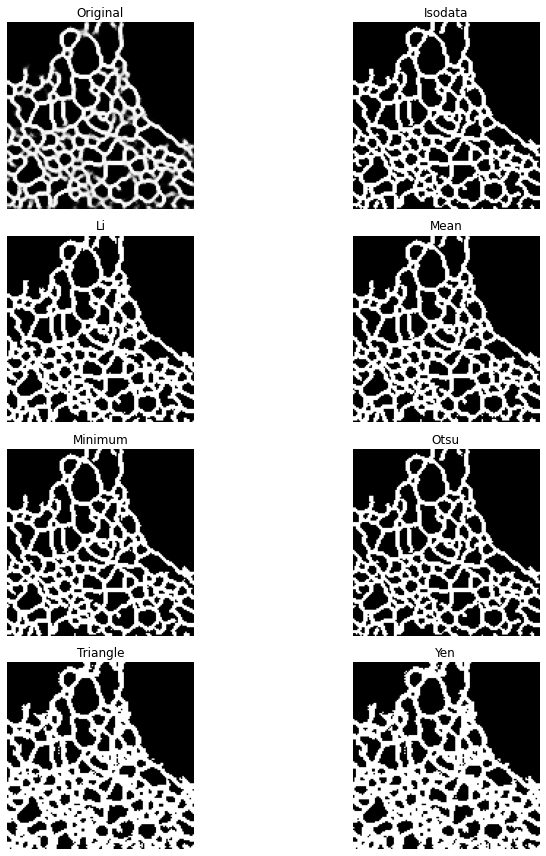

In [55]:
from skimage.filters import try_all_threshold
fig, ax = try_all_threshold(subt, figsize=(12, 12), verbose=False)

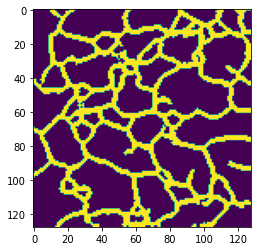

In [47]:
plt.imshow(subt > mul[0])

In [20]:
mul

array([0.23512769, 0.70538306], dtype=float32)

In [21]:
threshold_otsu(subt)

0.47219858

In [28]:
op1 = subt > tmin
op2 = subt >= tmin

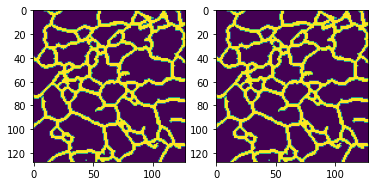

In [29]:
plt.subplot(121)
plt.imshow(op1)

plt.subplot(122)
plt.imshow(op2)

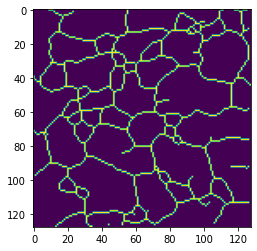

In [25]:
import skimage
sk = skimage.morphology.skeletonize(op)
plt.imshow(sk)

In [131]:
import imageio
import numpy as np
import skimage.io as io
# d = np.zeros((128, 128))

for seq in range(1, 32):
    d = []
    for i in range(100):
        img = imageio.imread(f'/localhome/asa420/MIAL/data/confocal-data/ATL/std/A{seq}_decon_t0{i:02d}_ch00_std.png')
        img = (img - img.min()) / (img.max() - img.min())
        d.append(img)
    kk = np.stack(d)    
    dv = np.var(kk, axis=0)
    dv = (dv).astype('float16')
    io.imsave(f'/localhome/asa420/MIAL/data/confocal-data/vess_enh_unet/atl/projection_var/A{seq}_proj_var.png', dv*255.)


Lossy conversion from float16 to uint8. Range [0.0, 16.265625]. Convert image to uint8 prior to saving to suppress this warning.
Lossy conversion from float16 to uint8. Range [0.0, 8.9921875]. Convert image to uint8 prior to saving to suppress this warning.
Lossy conversion from float16 to uint8. Range [0.0, 8.296875]. Convert image to uint8 prior to saving to suppress this warning.
Lossy conversion from float16 to uint8. Range [0.0, 10.5234375]. Convert image to uint8 prior to saving to suppress this warning.
Lossy conversion from float16 to uint8. Range [0.0, 8.4375]. Convert image to uint8 prior to saving to suppress this warning.
Lossy conversion from float16 to uint8. Range [0.0, 7.421875]. Convert image to uint8 prior to saving to suppress this warning.
Lossy conversion from float16 to uint8. Range [0.0, 7.37890625]. Convert image to uint8 prior to saving to suppress this warning.
Lossy conversion from float16 to uint8. Range [0.0, 9.859375]. Convert image to uint8 prior to savin

FileNotFoundError: No such file: '/localhome/asa420/MIAL/data/confocal-data/ATL/std/A27_decon_t000_ch00_std.png'

In [98]:
dv = np.var(kk, axis=0)
# dv.shape
# np.unique(dv)

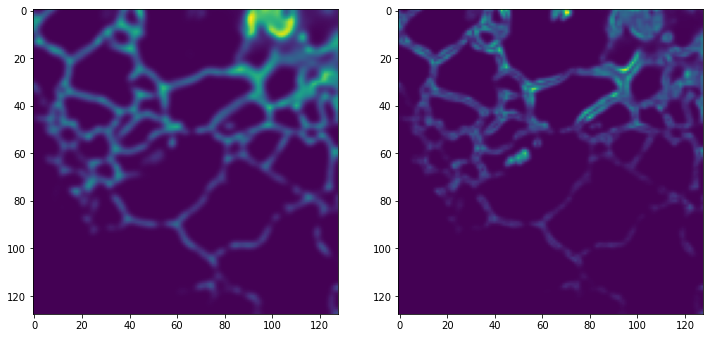

In [99]:
plt.figure(figsize=(12, 12))

plt.subplot(121)
plt.imshow(np.mean(kk, axis=0))

plt.subplot(122)
plt.imshow(dv)

In [118]:
from skimage.morphology import dilation
import sknw
skel = imageio.imread('/localhome/asa420/MIAL/data/confocal-data/vess_enh_unet/atl/skel/A1_decon_t000_ch00_skel.png')
img = imageio.imread('/localhome/asa420/MIAL/data/confocal-data/ATL/preproc/A1/A1_decon_t000_ch00_proc.png')

dilskel = dilation(skel)

graph = sknw.build_sknw(skel, iso=False, multi=False)

nodes_list = graph.nodes

junc = imageio.imread('/localhome/asa420/MIAL/data/confocal-data/vess_enh_unet/atl/junctions/A1_t0_junc.png')


# np.where(junc==255)

# np.unique(junc)

# plt.figure(figsize=(12, 12))

# plt.subplot(131)
# plt.imshow(skel)

# plt.subplot(132)
# plt.imshow(dilskel)

# plt.subplot(133)
# plt.imshow(np.zeros((128, 128)))

# node_set, degree_list = graph.nodes, graph.degree

# node_coords = np.array([node_set[node]['o'] for node in node_set])

# ps = np.array([node_coords[i] for i, val in enumerate(degree_list) if val[1] > 2])
# plt.plot(ps[:,1], ps[:,0], 'r.')

(369, 369, 4)